#### 1. CONFIGURACIÓN E IMPORTACIONES

In [13]:
print("--- 1. Importando librerías ---")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from sklearn.feature_extraction.text import CountVectorizer

# Descargar recursos de NLTK (solo necesario la primera vez que se ejecuta)
try:
    nltk.data.find('corpora/stopwords')
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Descargando recursos de NLTK (stopwords, punkt)...")
    nltk.download('stopwords')
    nltk.download('punkt')

# Configuraciones de visualización para un mejor aspecto
sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_colwidth', 200)
print("Librerías importadas y configuración completa.\n")

--- 1. Importando librerías ---
Librerías importadas y configuración completa.



#### 2. CARGA Y LIMPIEZA INICIAL DE DATOS

In [8]:
print("--- 2. Cargando y limpiando el dataset ---")

file_path = "../data/youtube_comment_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Dataset '{file_path}' cargado exitosamente. Forma del dataset: {df.shape}")
except FileNotFoundError:
    print("="*60)
    print(f"ERROR: No se encontró el archivo '{file_path}'.")
    print("Asegúrate de que el archivo está en el mismo directorio que tu notebook o proporciona la ruta completa.")
    print("="*60)
    # Detiene la ejecución si el archivo no se encuentra. Descomenta la línea de abajo si prefieres esto.
    # raise
    df = pd.DataFrame() # Crea un dataframe vacío para evitar que el resto del script falle

if not df.empty:
    # Identificar y definir roles de columnas
    id_cols = ['CommentId', 'VideoId']
    text_col = 'Text'
    label_cols = [col for col in df.columns if col.startswith('Is')]

    # Inspección básica
    print("\nPrimeras 5 filas del dataset:")
    display(df.head())
    print("\nInformación general y tipos de datos:")
    df.info()

    # Limpieza de nulos
    print(f"\nValores nulos antes de la limpieza en '{text_col}': {df[text_col].isnull().sum()}")
    df.dropna(subset=[text_col], inplace=True)
    print(f"Valores nulos después de la limpieza en '{text_col}': {df[text_col].isnull().sum()}")

    # Conversión de etiquetas de 'TRUE'/'FALSE' a 1/0
    for col in label_cols:
        df[col] = df[col].apply(lambda x: 1 if str(x).upper() == 'TRUE' else 0)

    print("\nTipos de datos después de la conversión de etiquetas:")
    df.info()
    print("Limpieza inicial completada.\n")

--- 2. Cargando y limpiando el dataset ---
Dataset '../data/youtube_comment_dataset.csv' cargado exitosamente. Forma del dataset: (1000, 15)

Primeras 5 filas del dataset:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,"If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation. To lump yourself into this mess and take matt...",False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that punk bitch.,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' banners being held by white cunts is kinda patronizing and ironically racist. could they have not come up with somethin better.. or is it just what whi...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do not like police officers. They are called Criminals and its the reason we have police officers. The fact that Criminals do not like police officers i...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should have not been shot 6 extra time. Shoot him once if hes attacking you and that would stop his attack. Shoot him twice if he's still attacking you, but s...",False,False,False,False,False,False,False,False,False,False,False,False



Información general y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CommentId        1000 non-null   object
 1   VideoId          1000 non-null   object
 2   Text             1000 non-null   object
 3   IsToxic          1000 non-null   bool  
 4   IsAbusive        1000 non-null   bool  
 5   IsThreat         1000 non-null   bool  
 6   IsProvocative    1000 non-null   bool  
 7   IsObscene        1000 non-null   bool  
 8   IsHatespeech     1000 non-null   bool  
 9   IsRacist         1000 non-null   bool  
 10  IsNationalist    1000 non-null   bool  
 11  IsSexist         1000 non-null   bool  
 12  IsHomophobic     1000 non-null   bool  
 13  IsReligiousHate  1000 non-null   bool  
 14  IsRadicalism     1000 non-null   bool  
dtypes: bool(12), object(3)
memory usage: 35.3+ KB

Valores nulos antes de la limpieza en 

#### 3. ANÁLISIS DE LAS ETIQUETAS (VARIABLE OBJETIVO)

--- 3. Analizando las etiquetas de odio ---


C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\2895983783.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


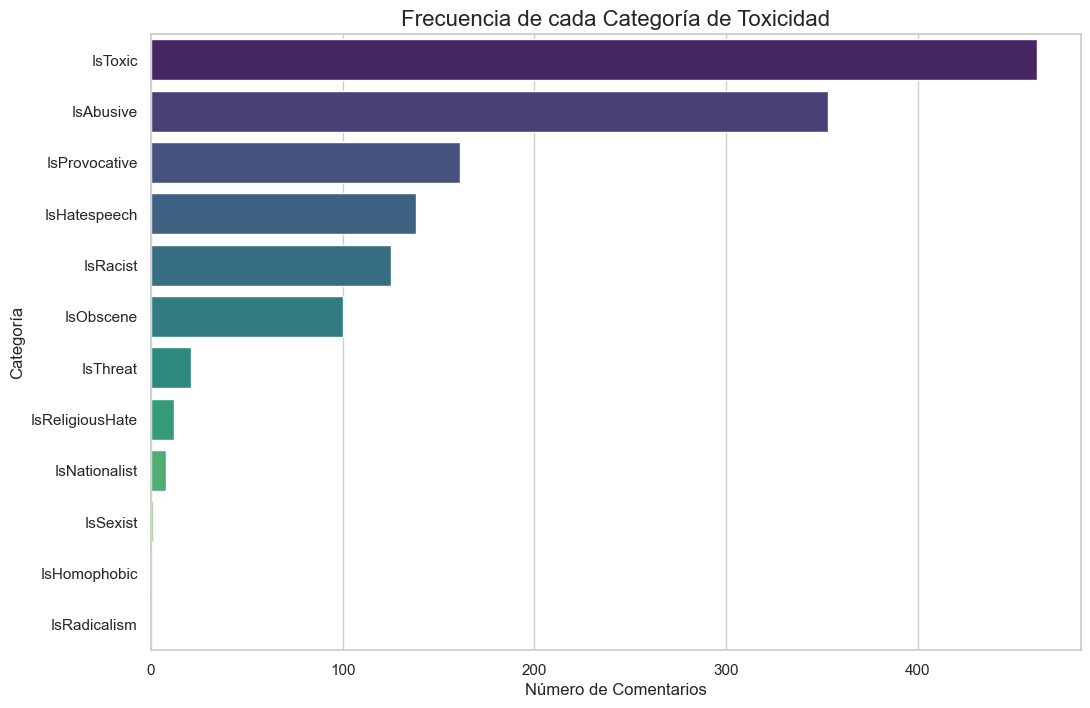

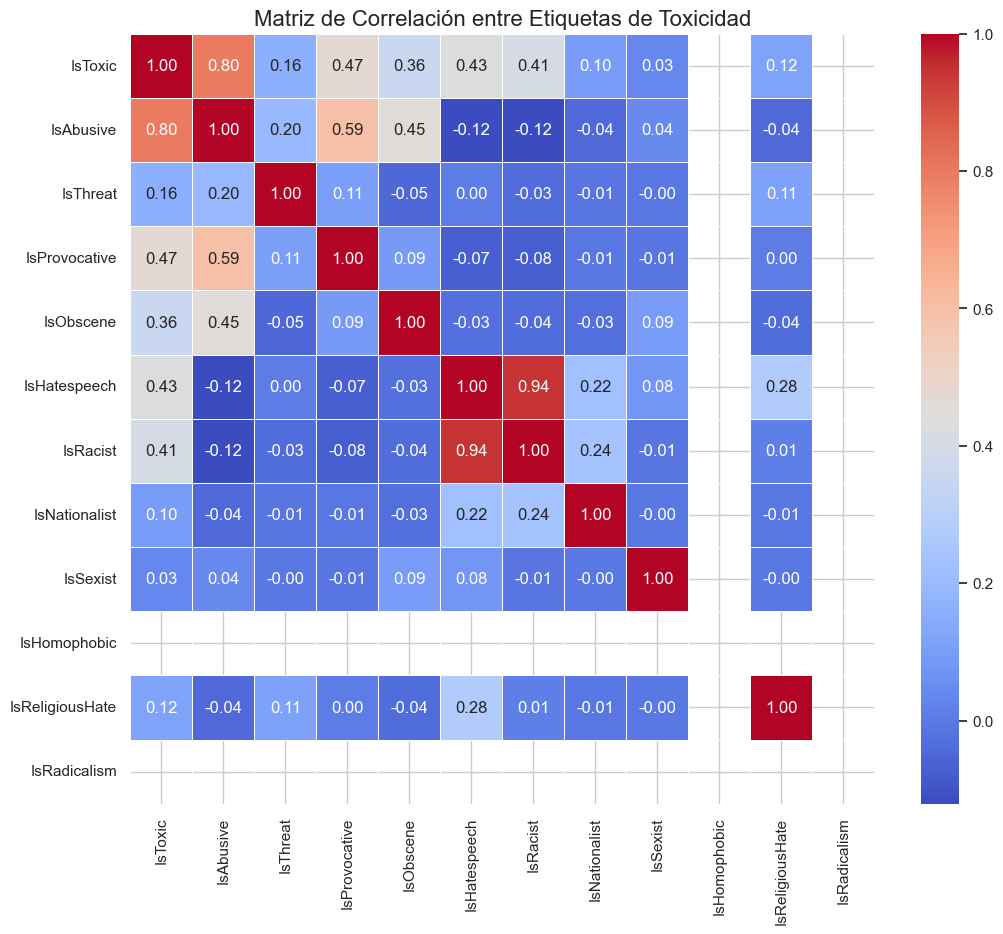


Análisis del desbalance de la clase unificada 'IsHate':
IsHate
0    53.8 %
1    46.2 %
Name: proportion, dtype: object


C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\2895983783.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsHate', data=df, palette='magma')


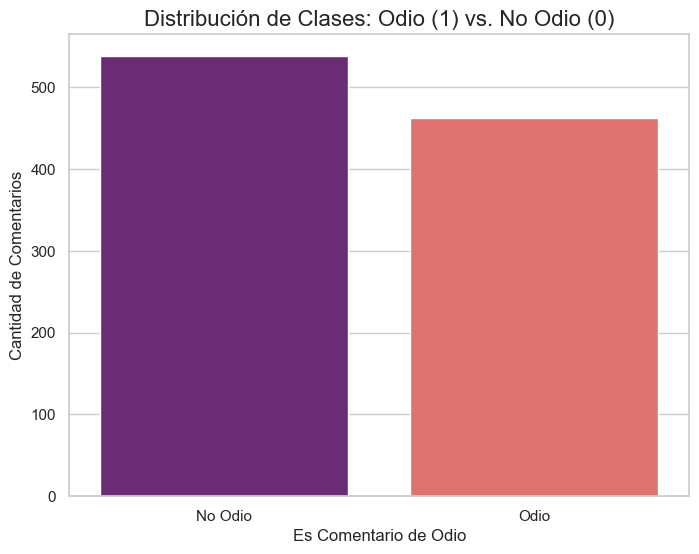

Análisis de etiquetas completado.



In [9]:
print("--- 3. Analizando las etiquetas de odio ---")

# 3.1. Distribución de etiquetas individuales
plt.figure(figsize=(12, 8))
label_counts = df[label_cols].sum().sort_values(ascending=False)
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.title('Frecuencia de cada Categoría de Toxicidad', fontsize=16)
plt.xlabel('Número de Comentarios', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.show()

# 3.2. Correlación entre etiquetas
plt.figure(figsize=(12, 10))
sns.heatmap(df[label_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación entre Etiquetas de Toxicidad', fontsize=16)
plt.show()

# 3.3. Creación de etiqueta binaria unificada 'IsHate'
df['IsHate'] = df[label_cols].any(axis=1).astype(int)

# 3.4. Análisis del desbalance de clases
print("\nAnálisis del desbalance de la clase unificada 'IsHate':")
print((df['IsHate'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')
plt.figure(figsize=(8, 6))
sns.countplot(x='IsHate', data=df, palette='magma')
plt.title('Distribución de Clases: Odio (1) vs. No Odio (0)', fontsize=16)
plt.xlabel('Es Comentario de Odio', fontsize=12)
plt.ylabel('Cantidad de Comentarios', fontsize=12)
plt.xticks([0, 1], ['No Odio', 'Odio'])
plt.show()
print("Análisis de etiquetas completado.\n")

#### 4. ANÁLISIS DEL CONTENIDO DEL TEXTO

--- 4. Analizando el contenido del texto ---


C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\3612658768.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='word_count', x='IsHate', ax=axes[1], palette='plasma')
C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\3612658768.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Odio', 'Odio'])


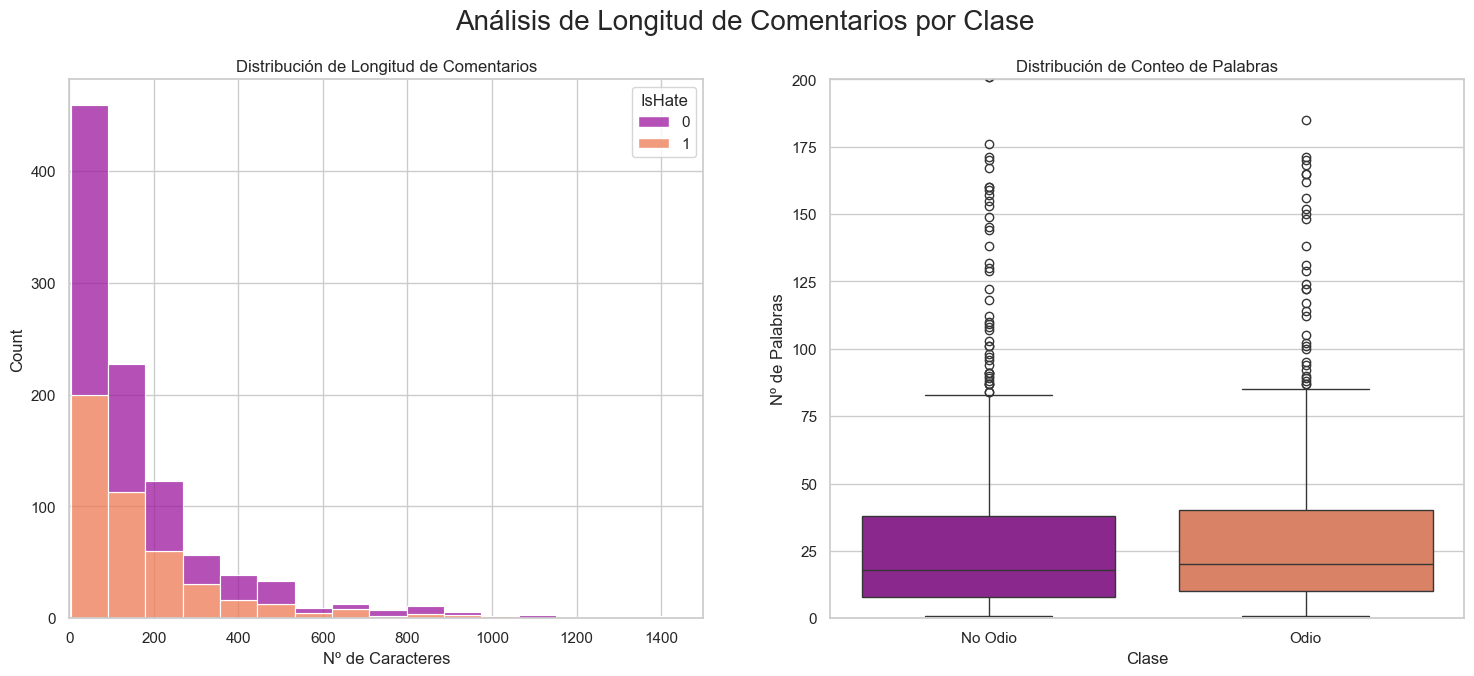

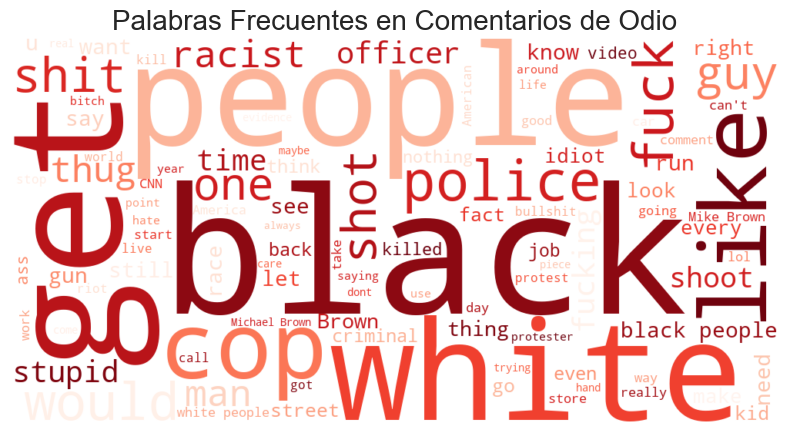

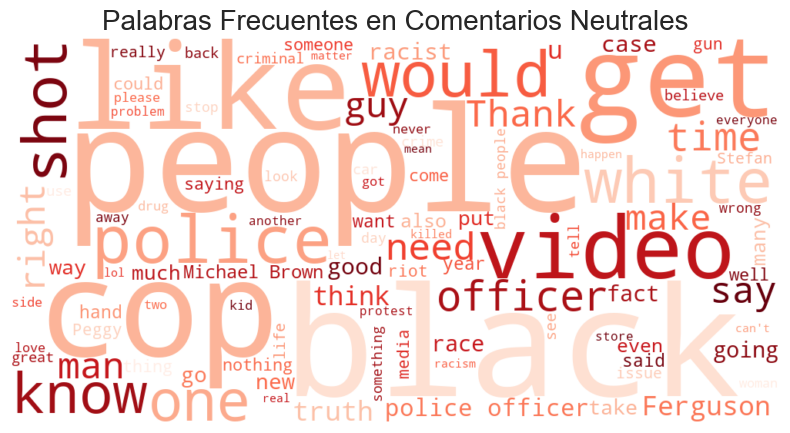


Análisis de Bigramas:


C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\3612658768.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Bigrama', x='Frecuencia', data=df_bigrams_hate, ax=axes[0], palette='Reds_r')
C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\3612658768.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Bigrama', x='Frecuencia', data=df_bigrams_non_hate, ax=axes[1], palette='Blues_r')


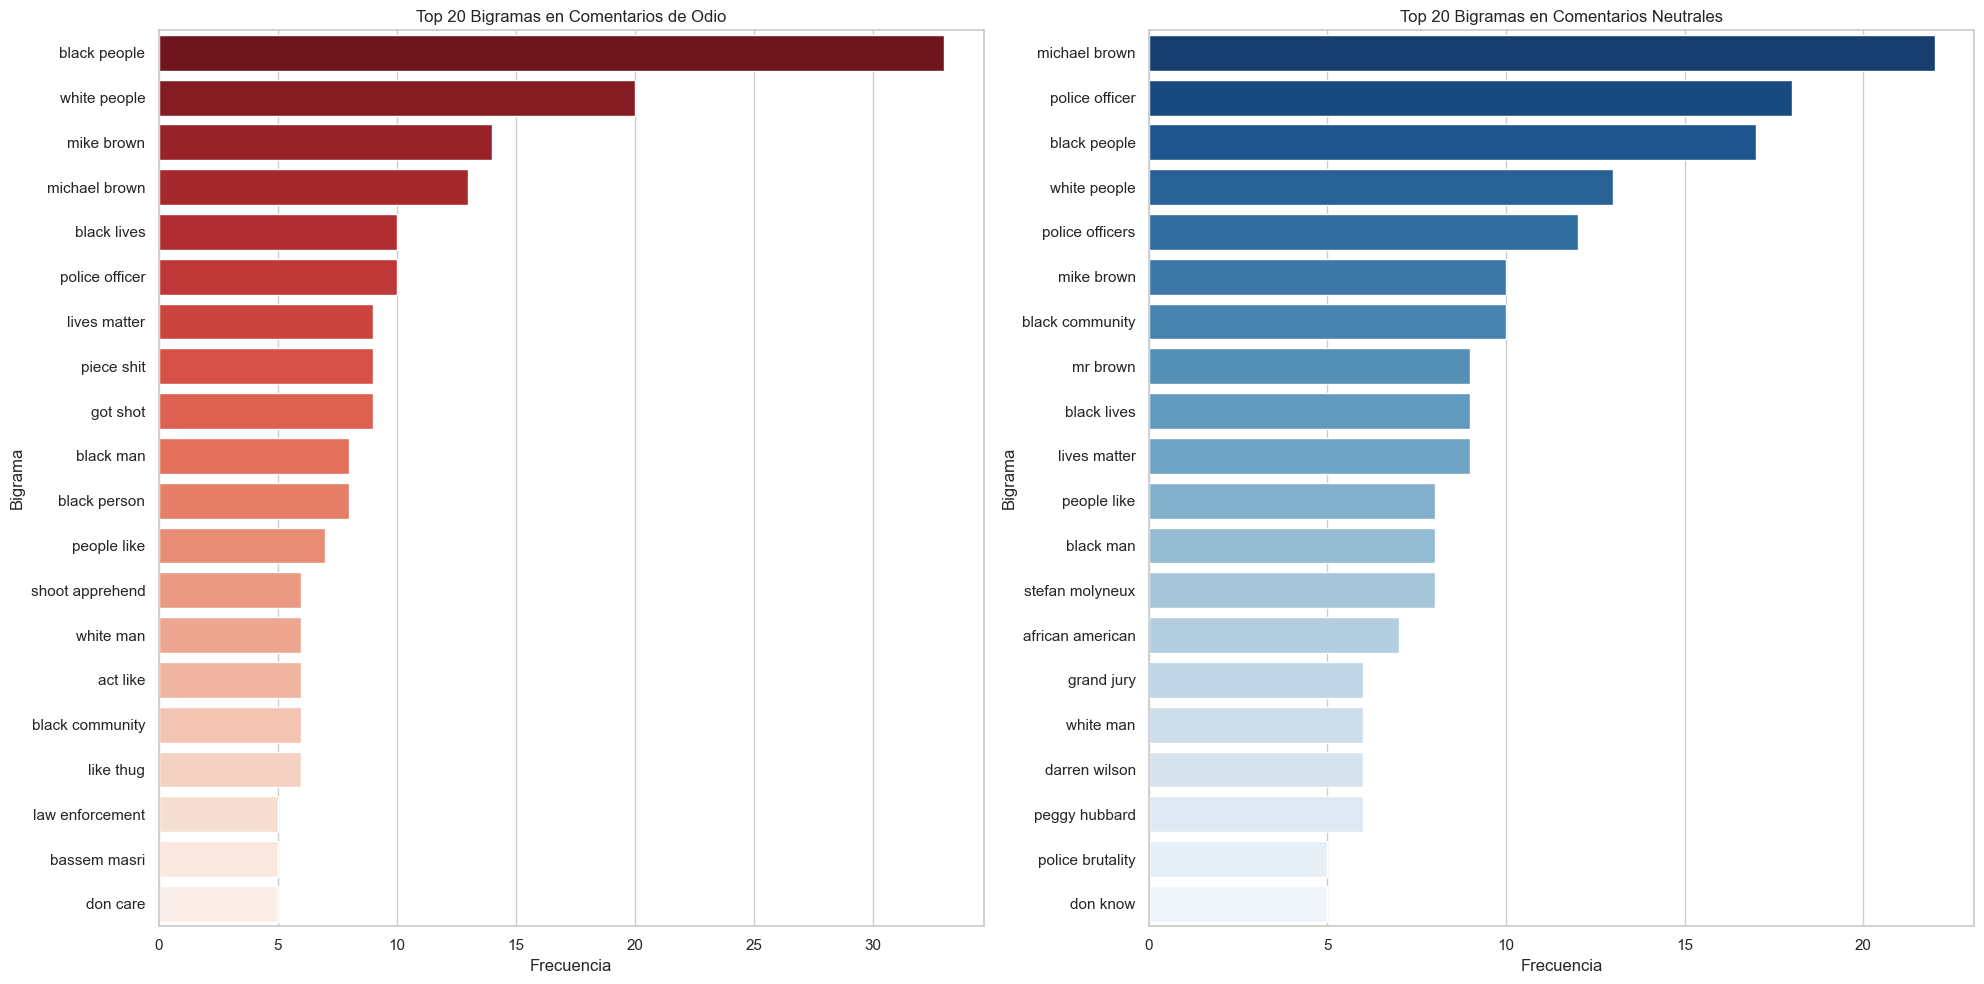

Análisis de contenido de texto completado.



In [10]:
print("--- 4. Analizando el contenido del texto ---")

# 4.1. Análisis de longitud
df['text_len'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.histplot(data=df, x='text_len', hue='IsHate', multiple='stack', bins=50, ax=axes[0], palette='plasma')
axes[0].set_title('Distribución de Longitud de Comentarios')
axes[0].set_xlim(0, 1500) # Limitar para mejor visualización
axes[0].set_xlabel('Nº de Caracteres')

sns.boxplot(data=df, y='word_count', x='IsHate', ax=axes[1], palette='plasma')
axes[1].set_title('Distribución de Conteo de Palabras')
axes[1].set_ylim(0, 200) # Limitar para mejor visualización
axes[1].set_ylabel('Nº de Palabras')
axes[1].set_xlabel('Clase')
axes[1].set_xticklabels(['No Odio', 'Odio'])

plt.suptitle('Análisis de Longitud de Comentarios por Clase', fontsize=20)
plt.show()

# 4.2. Nubes de Palabras (Unigramas)
stop_words_english = set(nltk.corpus.stopwords.words('english'))

def generate_wordcloud(text, title):
    wc = WordCloud(width=1000, height=500, background_color='white', stopwords=stop_words_english, max_words=100, colormap='Reds_r').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

hate_text = " ".join(comment for comment in df[df['IsHate'] == 1][text_col].astype(str))
non_hate_text = " ".join(comment for comment in df[df['IsHate'] == 0][text_col].astype(str))

if hate_text.strip():
    generate_wordcloud(hate_text, "Palabras Frecuentes en Comentarios de Odio")
if non_hate_text.strip():
    generate_wordcloud(non_hate_text, "Palabras Frecuentes en Comentarios Neutrales")

# 4.3. Análisis de N-gramas (Bigramas)
def get_top_n_grams(corpus, ngram_range=(2, 2), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

print("\nAnálisis de Bigramas:")
df_bigrams_hate = pd.DataFrame(get_top_n_grams(df[df['IsHate']==1][text_col].astype(str)), columns=['Bigrama', 'Frecuencia'])
df_bigrams_non_hate = pd.DataFrame(get_top_n_grams(df[df['IsHate']==0][text_col].astype(str)), columns=['Bigrama', 'Frecuencia'])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.barplot(y='Bigrama', x='Frecuencia', data=df_bigrams_hate, ax=axes[0], palette='Reds_r')
axes[0].set_title("Top 20 Bigramas en Comentarios de Odio")
sns.barplot(y='Bigrama', x='Frecuencia', data=df_bigrams_non_hate, ax=axes[1], palette='Blues_r')
axes[1].set_title("Top 20 Bigramas en Comentarios Neutrales")
plt.tight_layout()
plt.show()
print("Análisis de contenido de texto completado.\n")

#### 5. ANÁLISIS AGRUPADO POR VÍDEO

--- 5. Analizando patrones a nivel de vídeo ---


C:\Users\Omar\AppData\Local\Temp\ipykernel_2272\938708924.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=video_comment_counts.head(top_n).index, y=video_comment_counts.head(top_n).values, palette='mako')


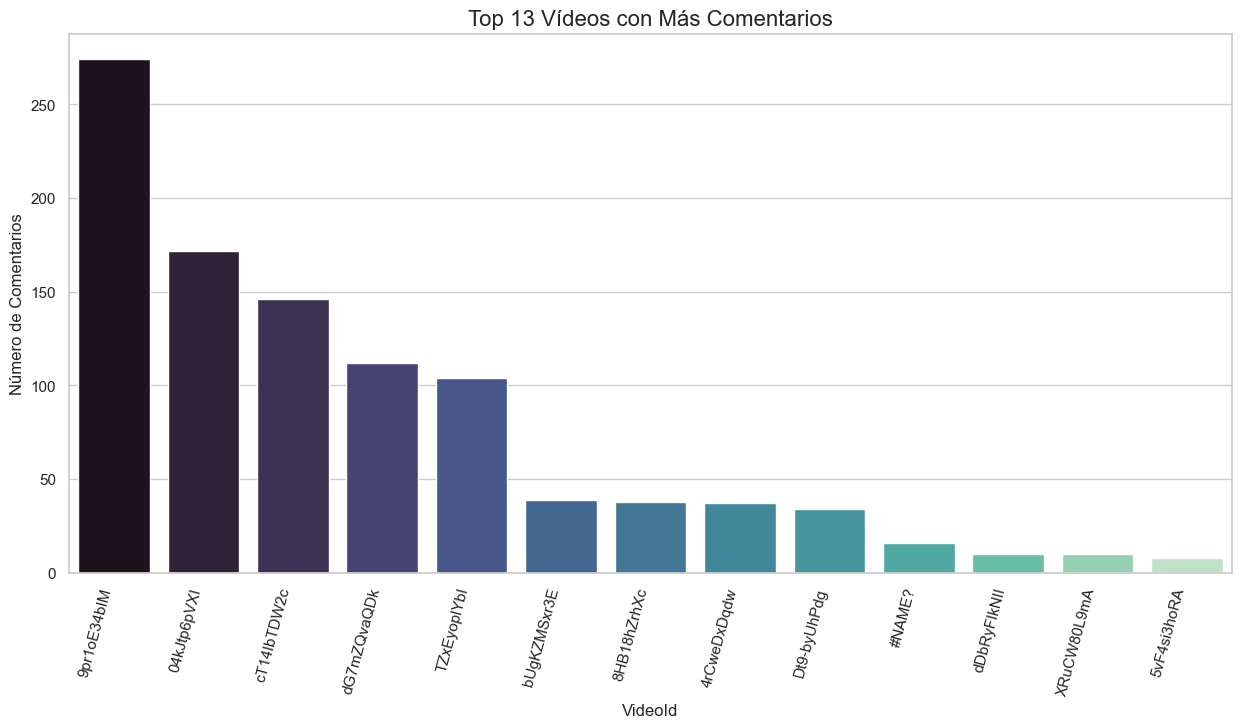

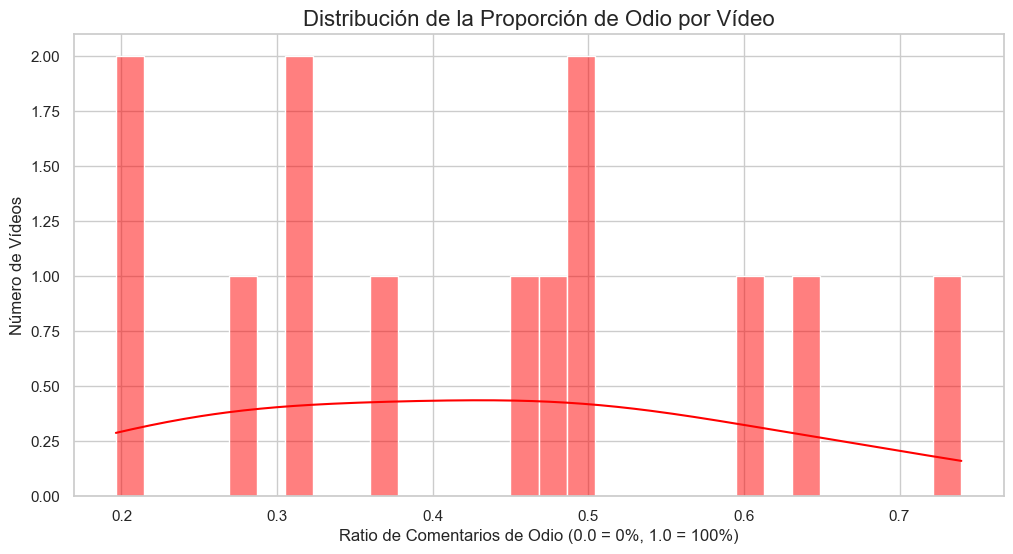


Análisis por vídeo completado.



In [11]:
print("--- 5. Analizando patrones a nivel de vídeo ---")

# 5.1. Distribución de comentarios por vídeo
video_comment_counts = df['VideoId'].value_counts()
top_n = min(20, len(video_comment_counts))
plt.figure(figsize=(15, 7))
sns.barplot(x=video_comment_counts.head(top_n).index, y=video_comment_counts.head(top_n).values, palette='mako')
plt.title(f'Top {top_n} Vídeos con Más Comentarios', fontsize=16)
plt.xlabel('VideoId', fontsize=12)
plt.ylabel('Número de Comentarios', fontsize=12)
plt.xticks(rotation=75, ha="right")
plt.show()

# 5.2. Proporción de odio por vídeo
video_hate_ratio = df.groupby('VideoId')['IsHate'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.histplot(video_hate_ratio, bins=30, kde=True, color='red')
plt.title('Distribución de la Proporción de Odio por Vídeo', fontsize=16)
plt.xlabel('Ratio de Comentarios de Odio (0.0 = 0%, 1.0 = 100%)', fontsize=12)
plt.ylabel('Número de Vídeos', fontsize=12)
plt.show()
print("\nAnálisis por vídeo completado.\n")